In [1]:
import sys
sys.path.append("../src")

In [2]:
from load_data import load_meetings
from preprocess import preprocess_dataframe
from topic_modeling import TopicModeler

df = load_meetings("../data/raw")

df = preprocess_dataframe(df)

In [3]:
tm = TopicModeler()

embeddings = tm.generate_embeddings(
    df["clean_summary"].tolist()
)

clusters = tm.cluster_texts(embeddings)

df["cluster"] = clusters

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [4]:
cluster_summary = (
    df.groupby("cluster")
    .agg({
        "sentiment_score": "mean",
        "duration": "mean",
        "meeting_id": "count"
    })
)

cluster_summary

,sentiment_score,duration,meeting_id
cluster,,,
-1,3.416,30.309,100


<Axes: xlabel='cluster'>

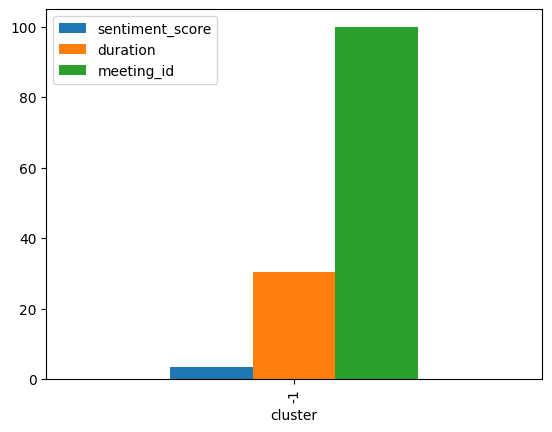

In [5]:
cluster_summary.plot(kind="bar")

In [6]:
for cluster_id in sorted(df["cluster"].unique()):

    sample = df[df["cluster"] == cluster_id]

    print("\n")
    print(f"CLUSTER {cluster_id}")

    print(sample["summary"].iloc[0])



CLUSTER -1
Jordan Whitfield and Tom Bradley conducted a competitive landscape review in preparation for an upcoming product review meeting. They discussed four key competitors: SentinelShield (threatening Detect with a strong SIEM integration story), VaultEdge (a growing threat to Protect and potentially Comply), CyberNova (aggressive pricing in Identity for mid-market), and Fortiguard Pro (a legacy incumbent). The most pressing concern identified was a gap in the LogVault connector experience compared to SentinelShield, which Jordan plans to surface as a risk item for leadership at next week's review. Jordan agreed to update and share the competitive deck before EOD the following day.
